In [1]:
# !find /home/david/FieldWork/Soufriere-Guadeloupe/Thermography/ -iname "*.irb*" -size +500M | sort

## TO DO
- Extract approximate plume trajectories for each
- Does "true_location_width" actually work?
- Update "parameters.json" files with actual distances, scaling factors etc.
- Convert pixel to world coordinates for trajectories

In [78]:
%reload_ext autoreload
%autoreload 3 -p
%matplotlib inline


from bent_plume_analyser import (gaussian_profile, show_scaled_image, image_extent,
                                 plume_angle, true_location_width, dist_along_path,
                                 read_params_file, save_params_file,
                                )
from fumarole_plume_model import derivs, load_ics_parameters, objective_fn, load_expt_data
from timeseries_analysis.timeseries_analysis import butter_lowpass_filtfilt
from scipy.io import loadmat
from scipy.integrate import ode, solve_ivp
from matplotlib.ticker import MultipleLocator

import pandas 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib as mpl
import os, sys
import json
import tifffile
import jupyprint as jp
import re
import pprint

# Set numpy options, notably for the printing of floating point numbers
np.set_printoptions(precision=6)

# Set matplotlib options
# mpl.rcParams['figure.dpi'] = 100
mpl.rcParams['image.cmap'] = 'gray'

Reloading 'bent_plume_analyser'.
Reloading 'bent_plume_analyser'.
Reloading 'bent_plume_analyser'.
Reloading 'bent_plume_analyser'.


In [2]:
ml_table = '''
|Date | Site | imAve | Trajectories| Scaled|
|-----|------|-------|-------------|-------|
|2017-10-31 | NAPE | False | False | False |
|2017-10-31 | NAPN | True  | False | False |
|2017-10-31 | CSS  | True  | True  | True  |
|2018-03-05 | CSC  | True  | False | False |
|2018-03-05 | CSN  | True  | True  | True  |
|2018-03-05 | CSS  | True  | True  | True  |
|2018-03-05 | G56  | False | False | False |
|2018-03-05 | NAPN | True  | False | False |
|2018-03-27 | CSC  | True  | False | False |
|2018-03-27 | CSN  | True  | True  | False |
|2018-03-27 | NAPE | True  | False | False |
|2018-03-27 | NAPN | True  | False | False |
|2018-05-02 | NAPN | True  | False | False |
|2019-01-08 | CSC  | True  | False | False |
|2019-01-08 | CSS  | True  | True  | False |
|2019-01-08 | NAPN | False | False | False |
|2019-01-10 | CSC  | False | False | False |
|2019-01-10 | CSN  | True  | True  | False |
|2019-01-10 | CSS  | True  | True  | True  |
|2019-01-10 | NAPN | False | False | False |
|2019-03-14 | CSN  | True  | False | False |
|2019-03-29 | NAPN | True  | False | False |
|2019-04-25 | CSC  | False | False | False |
|2019-04-25 | CSN  | False | False | False |
|2019-04-25 | CSS  | True  | True  | True  |
|2020-01-16 | CSS  | False | False | False |
|2020-01-30 | CSC  | True  | True  | True  |
|2020-01-30 | CSN  | True  | True  | True  |
|2020-01-30 | CSS  | True  | True  | True  |
|2020-01-30 | NAPN | False | False | False |
|2020-04-20 | CSC  | True  | False | False |
|2020-04-20 | CSN  | False | False | False |
|2020-04-20 | CSS  | False | False | False |
|2020-05-19 | CS*  | False | False | False |
|2020-05-19 | CSS  | True  | True  | True  |
|2020-06-23 | CS*  | False | False | False |
|2020-07-18 | CSN  | True  | True  | False |
|2020-07-18 | CSC  | True  | False | False |
|2020-07-18 | CSS  | False | False | False |
|2020-07-18 | ZFNN | False | False | False |
|2021-01-07 | CSN  | False | False | False |
|2021-01-07 | CSS  | False | False | False |
|2021-01-07 | NAPN | False | False | False |
|2021-01-07 | TAS  | False | False | False |
|2021-04-15 | CSC  | False | False | False |
|2021-04-15 | CSN  | False | False | False |
|2021-04-15 | CSS  | False | False | False |
'''
            
pattern = r"\|([\w\s\d-]+)? \| ([\w\s*]+) \| ([\w\s]+) \| ([\w\s]+) ?\| ([\w\s]+) ?\|"

# Use the findall function to extract all rows that match the pattern
matches = re.findall(pattern, ml_table)

# Extract the header and data rows
head = matches[0]
data = matches[1:]

# Create a pandas DataFrame using the extracted header and data rows
df = pd.DataFrame(data, columns=head)
df = df.set_index('Date')

for col in ['imAve', 'Trajectories', 'Scaled']:
    df[col] = df[col].str.contains('True')

df['Site'] = df['Site'].str.strip(' ')  # Clean up site names
# df['Date'] = pd.to_datetime(df['Date'])
# df['imAve'] = df['imAve'].astype(bool)
# df['Trajectories'] = df['Trajectories'].astype(bool)
df['Usable'] = np.logical_and(np.logical_and(*df[['imAve', 'Trajectories']].to_numpy().T), df['Scaled'])

filename = '/home/david/Modelling/fumarole_plume_model/list_of_observed_plumes.csv'
# if not os.path.exists(filename):
df.to_csv(filename)
jp.jupyprint(df.loc[df['Usable']].to_markdown())
jp.jupyprint(df.loc[~df['Usable']].to_markdown())

# fieldwork = '/home/david/FieldWork/Soufriere-Guadeloupe/Thermography/'
# for ind, row in df.iterrows():
#     observation = row['Date'] + '_' + row['Site']
#     filename    = observation.strip(' ') + '/' + observation.replace('-', '').strip(' ') + '_imAve_bt.tif'
#     print(f'{filename:21s} {os.path.exists(fieldwork + filename)}')

| Date       | Site   | imAve   | Trajectories   | Scaled   | Usable   |
|:-----------|:-------|:--------|:---------------|:---------|:---------|
| 2017-10-31 | CSS    | True    | True           | True     | True     |
| 2018-03-05 | CSN    | True    | True           | True     | True     |
| 2018-03-05 | CSS    | True    | True           | True     | True     |
| 2019-01-10 | CSS    | True    | True           | True     | True     |
| 2019-04-25 | CSS    | True    | True           | True     | True     |
| 2020-01-30 | CSC    | True    | True           | True     | True     |
| 2020-01-30 | CSN    | True    | True           | True     | True     |
| 2020-01-30 | CSS    | True    | True           | True     | True     |
| 2020-05-19 | CSS    | True    | True           | True     | True     |

| Date       | Site   | imAve   | Trajectories   | Scaled   | Usable   |
|:-----------|:-------|:--------|:---------------|:---------|:---------|
| 2017-10-31 | NAPE   | False   | False          | False    | False    |
| 2017-10-31 | NAPN   | True    | False          | False    | False    |
| 2018-03-05 | CSC    | True    | False          | False    | False    |
| 2018-03-05 | G56    | False   | False          | False    | False    |
| 2018-03-05 | NAPN   | True    | False          | False    | False    |
| 2018-03-27 | CSC    | True    | False          | False    | False    |
| 2018-03-27 | CSN    | True    | True           | False    | False    |
| 2018-03-27 | NAPE   | True    | False          | False    | False    |
| 2018-03-27 | NAPN   | True    | False          | False    | False    |
| 2018-05-02 | NAPN   | True    | False          | False    | False    |
| 2019-01-08 | CSC    | True    | False          | False    | False    |
| 2019-01-08 | CSS    | True    | True           | False    | False    |
| 2019-01-08 | NAPN   | False   | False          | False    | False    |
| 2019-01-10 | CSC    | False   | False          | False    | False    |
| 2019-01-10 | CSN    | True    | True           | False    | False    |
| 2019-01-10 | NAPN   | False   | False          | False    | False    |
| 2019-03-14 | CSN    | True    | False          | False    | False    |
| 2019-03-29 | NAPN   | True    | False          | False    | False    |
| 2019-04-25 | CSC    | False   | False          | False    | False    |
| 2019-04-25 | CSN    | False   | False          | False    | False    |
| 2020-01-16 | CSS    | False   | False          | False    | False    |
| 2020-01-30 | NAPN   | False   | False          | False    | False    |
| 2020-04-20 | CSC    | True    | False          | False    | False    |
| 2020-04-20 | CSN    | False   | False          | False    | False    |
| 2020-04-20 | CSS    | False   | False          | False    | False    |
| 2020-05-19 | CS*    | False   | False          | False    | False    |
| 2020-06-23 | CS*    | False   | False          | False    | False    |
| 2020-07-18 | CSN    | True    | True           | False    | False    |
| 2020-07-18 | CSC    | True    | False          | False    | False    |
| 2020-07-18 | CSS    | False   | False          | False    | False    |
| 2020-07-18 | ZFNN   | False   | False          | False    | False    |
| 2021-01-07 | CSN    | False   | False          | False    | False    |
| 2021-01-07 | CSS    | False   | False          | False    | False    |
| 2021-01-07 | NAPN   | False   | False          | False    | False    |
| 2021-01-07 | TAS    | False   | False          | False    | False    |
| 2021-04-15 | CSC    | False   | False          | False    | False    |
| 2021-04-15 | CSN    | False   | False          | False    | False    |
| 2021-04-15 | CSS    | False   | False          | False    | False    |

25 7 4 False


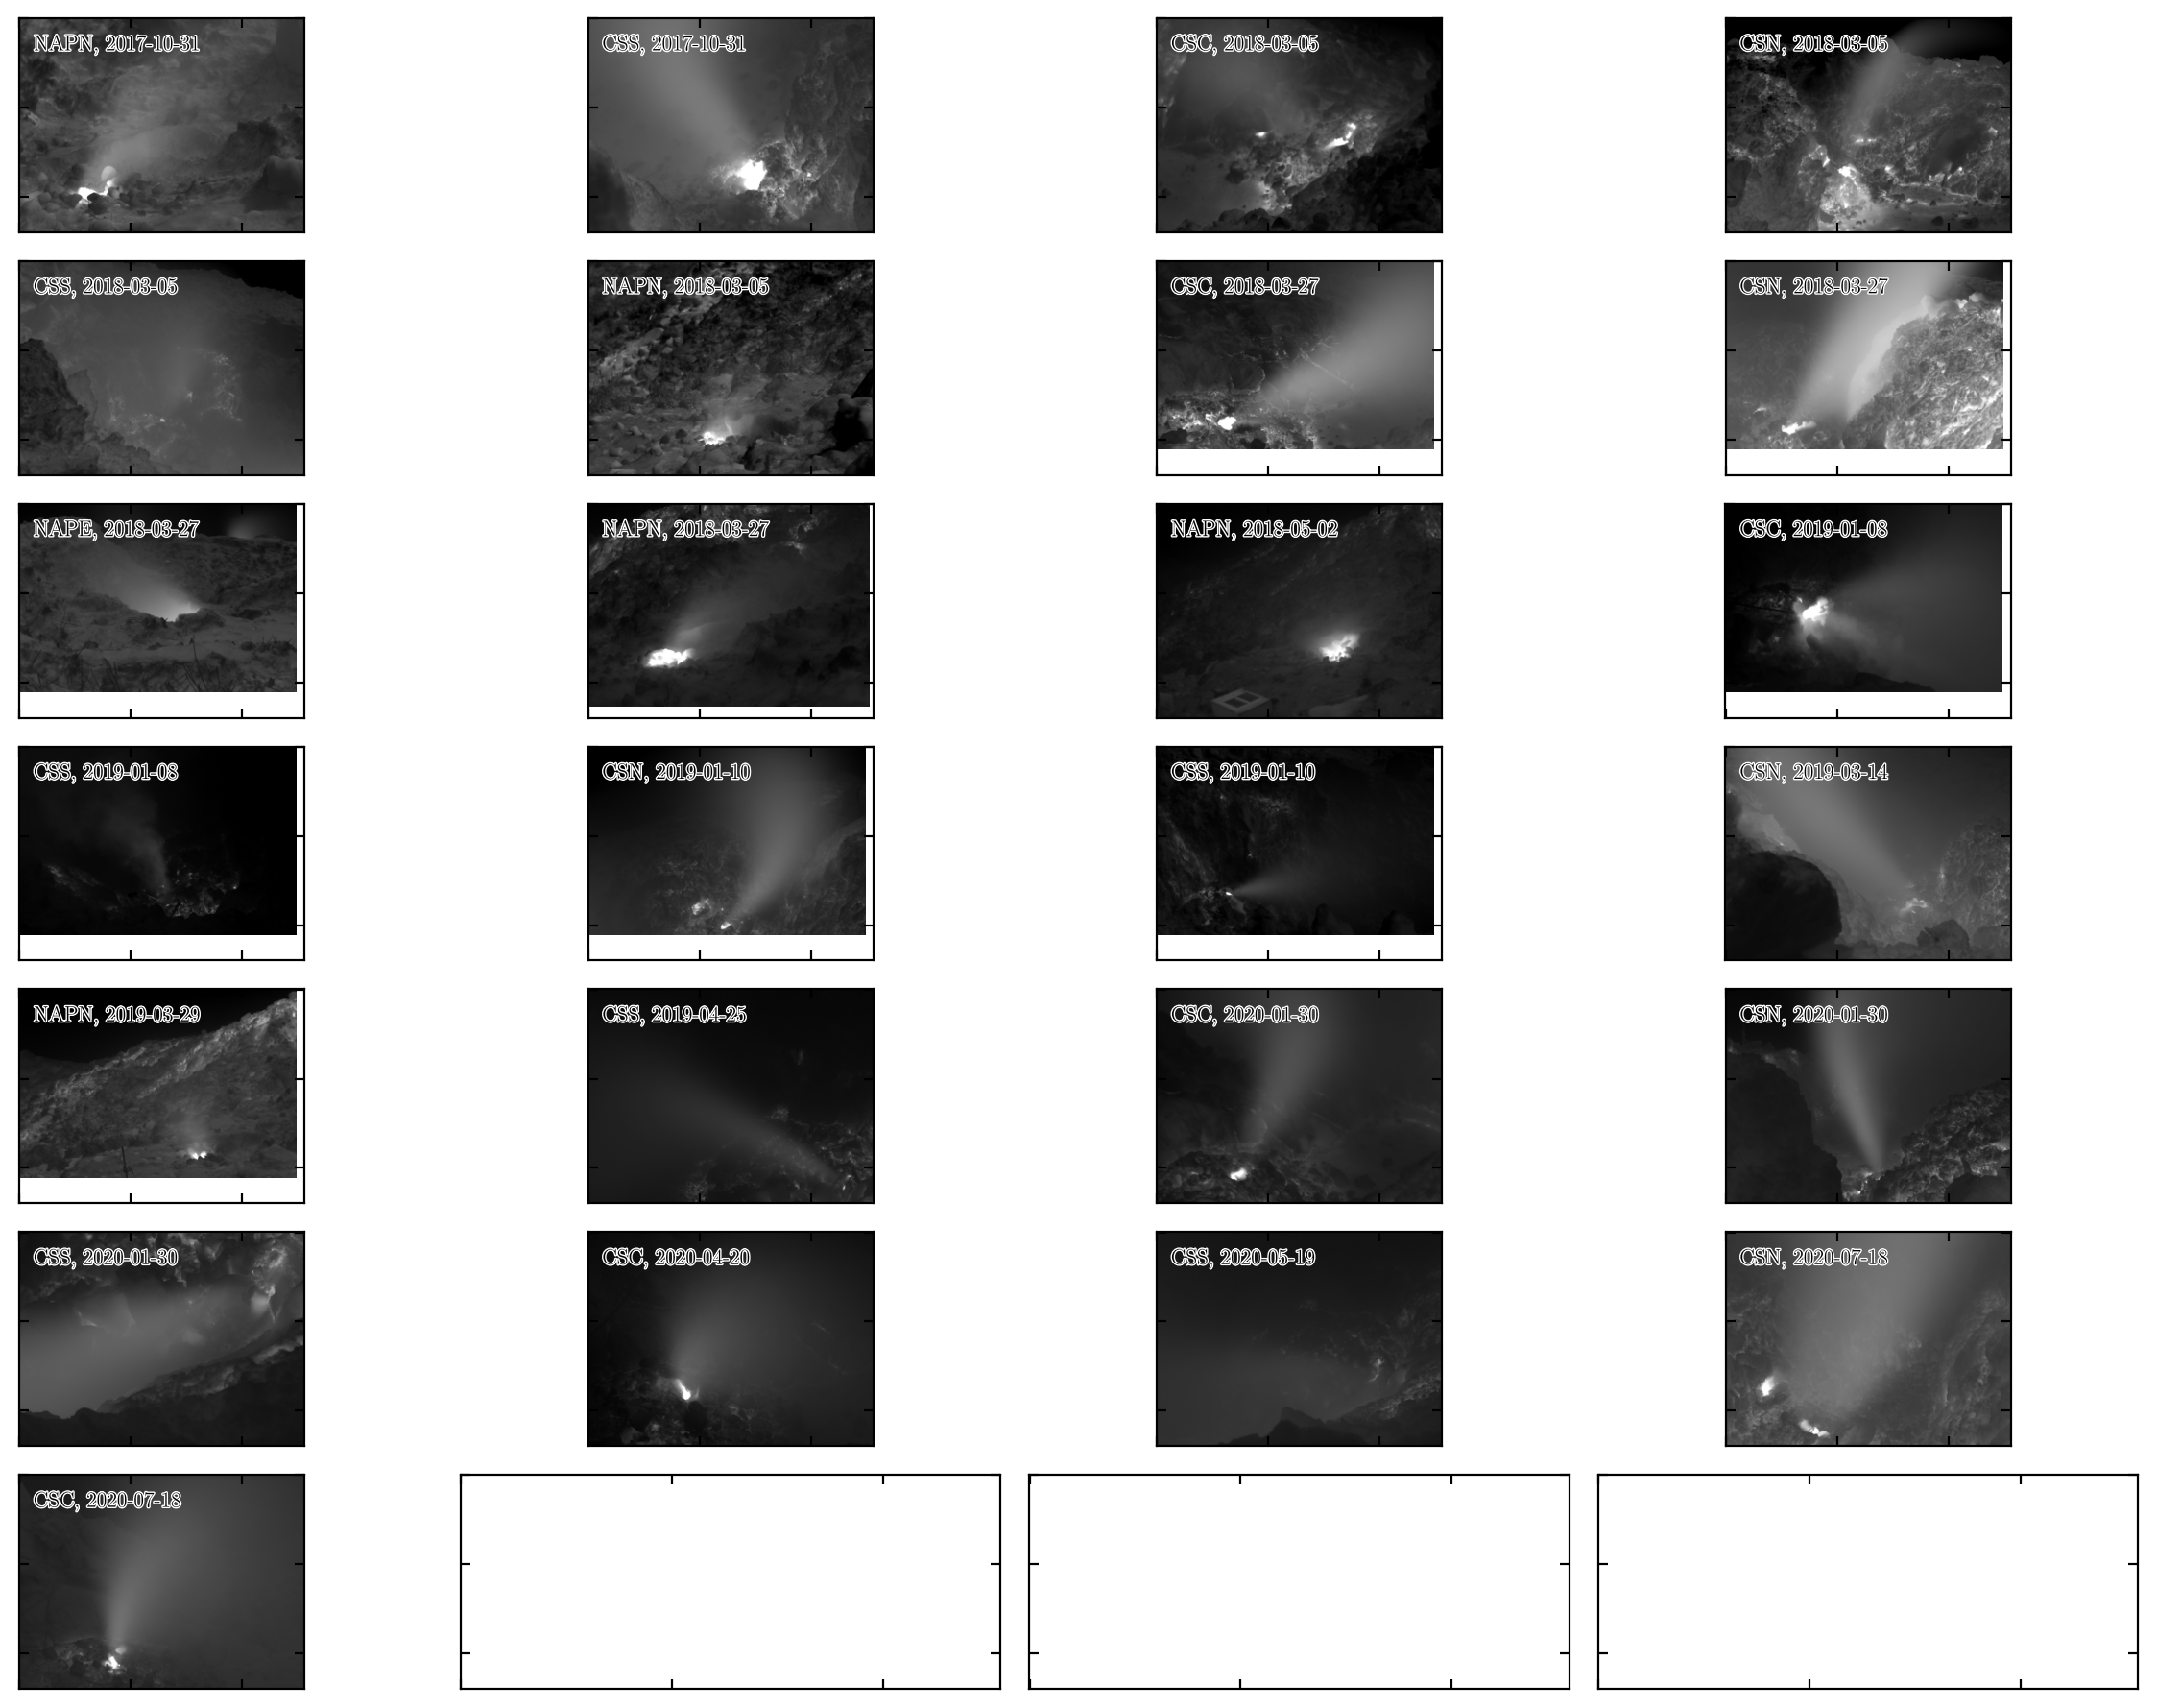

In [62]:
thermography = '/home/david/FieldWork/Soufriere-Guadeloupe/Thermography/'

usable = df.loc[df['imAve']]
# usable = sorted(glob(thermography + '*/*_imAve_bt.tif'))
N  = len(usable)
nc = 4
nr = N // nc  # always have "nc" columns
# nc = int(np.ceil(N / nr))
if nr * nc < N:
    nr += 1
print(N, nr, nc, nr * nc < N)

fig, axes = plt.subplots(nrows=nr, ncols=nc, dpi=200, figsize=(12, 9), sharex=True, sharey=True)

for ax, (ind, row) in zip(axes.flatten(), usable.iterrows()):
    path    = thermography + row.name + '_' + row['Site'] + '/'  
    im_path = path + row.name.replace('-', '') + '_' + row['Site'] + '_imAve_bt.tif'
    # try: 
    #     with open(path + 'parameters.json', 'r') as f:
    #         params = json.load(f)
    #     trajectory = params['trajectory']
    #     extent     = params['extent']
    # except FileNotFoundError as e:
    #     pass

# for ax, im_path in zip(axes.flatten(), usable):
#     path  = '/'.join(im_path.split('/')[:-1]) + '/'
    image = tifffile.imread(im_path)
    ax.imshow(image, vmax=60, vmin=15, cmap='gray') #, extent=extent)
    ax.annotate(f'{row['Site']}, {row.name}', (.05, .85), xycoords='axes fraction', color='k', fontsize='small',
                  path_effects=[pe.withStroke(linewidth=1, foreground="w")])
    # ax.xaxis.set_visible(False)
    # ax.yaxis.set_visible(False)
    ax.set_xticklabels([])
    ax.set_yticklabels([])


# fig.supxlabel('Image horizontal extent/[m]')
# fig.supylabel('Image vertical extent/[m]')
fig.tight_layout();
fig.savefig(thermography + 'all_plume_images.png')

## Natural plumes

In [75]:
def _line(x, y, th, width=.5):
    x_ = np.array([-width, width])
    y_ = (x_) / np.tan(-th)
    return x_ + x, y_ + y


def plume_analysis(date, site, thermography=thermography):
    path = '/'.join([thermography, date + '_' + site])
    im_path = path + '/' + date.replace('-', '') + '_' + site + '_imAve_bt.tif'
    data = tifffile.imread(im_path)
    # img   = np.flipud(img)
    params_file = path + '/parameters.json'
    
    params = read_params_file(params_file)
    
    extent       = params['extent']
    trajectory   = params['trajectory']
    scale_factor = params['scale_factor']
    
    vent_loc     = params['vent_loc']
    image_shape  = params['image_shape']
    
    vent_loc[1]  = image_shape[0] - vent_loc[1]
    extent       = image_extent(image_shape, scale_factor, vent_loc)
    
    trajectory   = np.array(trajectory)
    trajectory[:,1] = image_shape[0] - trajectory[:,1]
    
    real_trajectory = (trajectory - [vent_loc[0], vent_loc[1]]) * 1/scale_factor
    p = real_trajectory.copy()
    
    
    thexp, sig_thexp = plume_angle(p[:,0], p[:,1], errors=[1/scale_factor]*2)
    # thexp[0] = np.pi/2
    true_loc, bexp, sig_p, sig_bexp, rows = true_location_width(img, p=trajectory, errors=[1/scale_factor], retrows=True)
    sexp      = dist_along_path(p[:,0], p[:,1])
        
    ############
    # Plotting #
    ############
    fig, axes = plt.subplots(ncols=2, sharey=False)
    extent, im, ax = show_scaled_image(data, scale_factor, vent_loc, ax=axes[0])
    # ax.plot(0, 0, 'or')  # vent location
    
    ## DEFINE THE DISTANCE ALONG THE AXIS, THE ANGLE AND THE WIDTH OF THE PLUME
    pPixels = p.copy() * scale_factor + vent_loc
    pPixels *= [1, -1]
    pPixels += [0, 2*n]
    
    ax.plot(p[:,0], p[:,1], '--.r', lw=.8)
    ax.set_xlabel('Horizontal distance/[m]')
    ax.set_ylabel('Vertical distance/[m]')
    ax.set_title('Time-averaged TIR image')
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.yaxis.set_minor_locator(MultipleLocator(1))
    
    thexp, sig_thexp = plume_angle(p[:,0], p[:,1], errors=[1/scale_factor]*2)
    _, bexp, sig_p, sig_bexp = true_location_width(data, p=pPixels, errors=[1/scale_factor])
    sexp      = dist_along_path(p[:,0], p[:,1])
    bexp     /= scale_factor
    sig_bexp /= scale_factor

    for th, p_ in zip(thexp, p):
        xs, ys = p_
        x_, y_ = _line(xs, ys, th, width=.8)
        ax.plot(x_, y_, '--r', lw=.5)
    
    axes[1].errorbar(bexp, sexp, ls='none', marker='.', c='k', xerr=sig_bexp)
    axes[1].set_xlabel('Plume width/[m]')
    axes[1].set_ylabel('Distance along plume axis/[m]')
    axes[1].set_title('Plume parameters')
    
    fig.suptitle(f'{date}, {site}');
    fig.savefig(path + f'/{date}_{site}_analysis.png');

    ###############
    # UPDATE JSON #
    ###############
    params['real_trajectory'] = real_trajectory.tolist()
    params['sexp'] = sexp.tolist()
    params['bexp'] = bexp.tolist()
    params['sig_bexp'] = sig_bexp.tolist()
    
    if os.path.isfile(params_file):
        if not os.path.isfile(params_file + '.' + dt.now().strftime('%Y%m%d')):
            os.rename(params_file, params_file + '.' + dt.now().strftime('%Y%m%d'))
    save_params_file(params, params_file)

    return 

Reloading 'bent_plume_analyser'.
Reloading 'bent_plume_analyser'.
Reloading 'bent_plume_analyser'.
Reloading 'bent_plume_analyser'.
Reloading 'bent_plume_analyser'.


/home/david/Modelling/fumarole_plume_model/bent_plume_analyser.py:449: RuntimeWarning: invalid value encountered in sqrt
  plume_width_err.append(np.sqrt(np.diag(pcov[-1])))


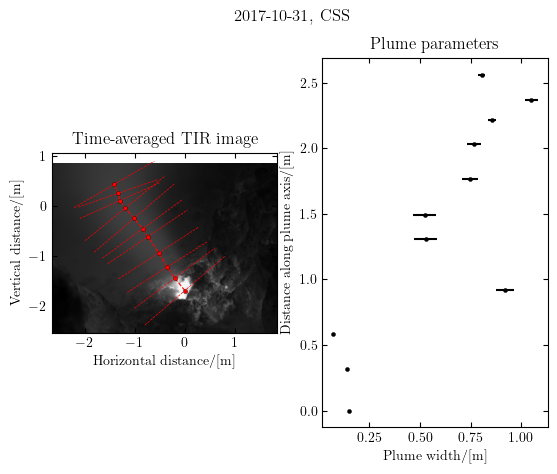

In [82]:
site = 'CSS'
date = '2017-10-31'

# path = '/'.join([thermography, date + '_' + site]) + '/'
# params = read_params_file(path + 'parameters.json')

# # params['trajectory'] = params['trajectory'][:-2]
# # params['real_trajectory'] = params['real_trajectory'][:-2]
# # params['sexp'] = params['sexp'][:-2]
# # params['bexp'] = params['bexp'][:-2]
# # params['sig_bexp'] = params['sig_bexp'][:-2]

# pprint.pp(params)

# # save_params_file(params, params_file)

plume_analysis(date, site)

/home/david/Modelling/fumarole_plume_model/bent_plume_analyser.py:449: RuntimeWarning: invalid value encountered in sqrt
  plume_width_err.append(np.sqrt(np.diag(pcov[-1])))


ValueError: index can't contain negative values

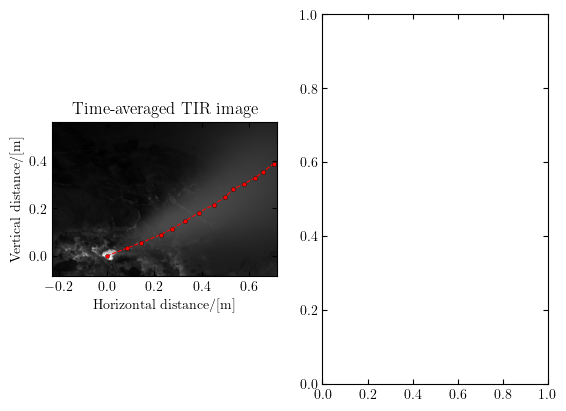

In [63]:
date = '2018-03-27'
site = 'CSC'

plume_analysis(date, site)

In [7]:
# # DO NOT CHANGE THESE VALUES
# # 2018-03-05 ONLY !!!
# date  = '2018-03-05'
# site  = 'CSN'
# path  = f'/home/david/FieldWork/Soufriere-Guadeloupe/Thermography/{date}_{site}/'  #2018-03-05_CSN/'

# vent_loc     = (265.5194805194804, 480-348.07142857142856)
# dist_to_vent = 8.44  # m, from logbook
# wind_speed   = 1     # m/s
# IFOV         = 1.53e-3  # rad - 15 mm IRBIS lens with FOV = 43.6
# scale_factor = 1 / (2 * dist_to_vent * np.arctan(IFOV / 2))  # m / pixel
# image_shape  = [480, 640]
# extent       = image_extent(image_shape, scale_factor, vent_loc)

# ## DEFINE THE DISTANCE ALONG THE AXIS, THE ANGLE AND THE WIDTH OF THE PLUME
# p = [[ 0.05      , 0.        ],
#      [ 0.06655528, 0.13287715],
#      [ 0.09434369, 0.45939095],
#      [ 0.1429734 , 0.84842867],
#      [ 0.23328573, 1.18883667],
#      [ 0.30275675, 1.48061496],
#      [ 0.455593  , 1.79323456],
#      [ 0.55979953, 2.06417155],
#      [ 0.65011186, 2.28647881],
#      [ 0.82378941, 2.5643629 ],
#      [ 1.01136117, 2.83529988],
#      [ 1.23366844, 3.23128471],
#      [ 1.31703366, 3.46053908],
#      [ 1.46986991, 3.68979345],
#      [ 1.61575906, 3.90073043],
#      [ 1.78943661, 4.06493696],
#      [ 2.09510911, 4.1760906 ],
#      [ 2.67171858, 4.42618627]]


# image_data = {'vent_loc':  vent_loc, 
#               'dist_to_vent': dist_to_vent,
#               'wind_speed': wind_speed,
#               'IFOV': IFOV,
#               'scale_factor': scale_factor,
#               'extent': list(extent),
#               'image_shape': image_shape,
#               'trajectory': p}

# with open(path + 'parameters.json', 'w') as f:
#     json.dump(image_data, f)

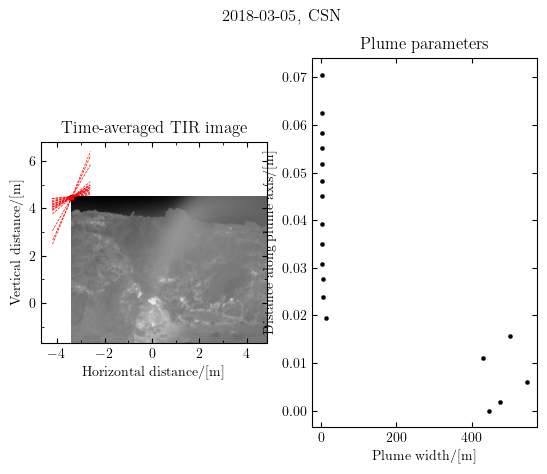

In [55]:
date  = '2018-03-05'
site  = 'CSN'

plume_analysis(date, site)

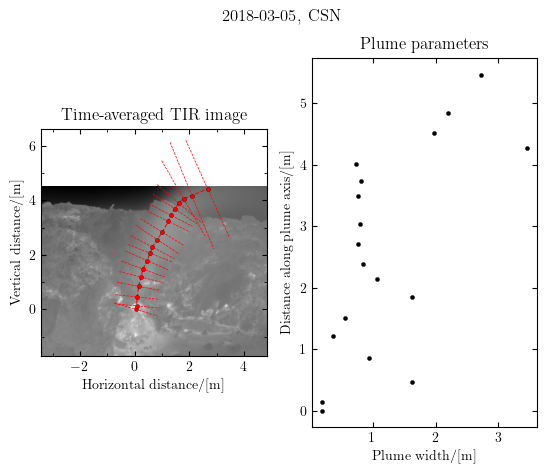

In [32]:
# fname = '20180305_CSN_imAve_bt.tif'
date  = '2018-03-05'
site  = 'CSN'
fname = f'{date.replace('-', '')}_{site}_imAve_bt.tif'

path  = thermography + date + '_' + site + '/'
data  = tifffile.imread(path + fname)
n, m  = np.array(data.shape) // 2

with open(path + 'parameters.json', 'r') as f:
    parameters = json.load(f)

fig, axes = plt.subplots(ncols=2, sharey=False)
extent, im, ax = show_scaled_image(data, scale_factor, vent_loc, ax=axes[0])
# ax.plot(0, 0, 'or')  # vent location

## DEFINE THE DISTANCE ALONG THE AXIS, THE ANGLE AND THE WIDTH OF THE PLUME
p = np.array(parameters['trajectory'])
scale_factor = parameters['scale_factor']
vent_loc     = parameters['vent_loc']

# pPixels = p.copy() * scale_factor + vent_loc
# pPixels *= [1, -1]
# pPixels += [0, 2*n]

ax.plot(p[:,0], p[:,1], '--.r', lw=.8)
ax.set_xlabel('Horizontal distance/[m]')
ax.set_ylabel('Vertical distance/[m]')
ax.set_title('Time-averaged TIR image')
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(MultipleLocator(1))

thexp, sig_thexp = plume_angle(p[:,0], p[:,1], errors=[1/scale_factor]*2)
# thexp[0] = np.pi/2
_, bexp, sig_p, sig_bexp = true_location_width(data, p=pPixels, errors=[1/scale_factor])
sexp      = dist_along_path(p[:,0], p[:,1])
bexp     /= scale_factor
sig_bexp /= scale_factor
    
for th, p_ in zip(thexp, p):
    xs, ys = p_
    x_, y_ = _line(xs, ys, th, width=.8)
    ax.plot(x_, y_, '--r', lw=.5)
    # with np.printoptions(precision=3, suppress=False):
    #     print(f'{th:.3f}, {xs:.3f}, {ys:.3f}', x_, y_)

# print(np.vstack([bexp, sexp]).T)
# fig, ax = plt.subplots()
axes[1].plot(bexp, sexp, '.k')
# axes[1].set_xlim([-10, 210])
axes[1].set_xlabel('Plume width/[m]')
axes[1].set_ylabel('Distance along plume axis/[m]')
axes[1].set_title('Plume parameters')
# axes[1].xaxis.set_minor_locator(MultipleLocator(20))
# axes[1].xaxis.set_major_locator(MultipleLocator(100))
# axes[1].yaxis.set_minor_locator(MultipleLocator(.5))

fig.suptitle(f'{date}, {site}');

## Experimental plumes

In [10]:
## Analysis of an experiment for a wind-bent plume (Carazzo et al., 2016)
exptNo = 3
# sexp  = exptData.distAlongAxis
# thexp = exptData.plumeAngle
# bexp  = exptData.plumeWidth
scale_factor = 1./72.

path = './data/ExpPlumes_for_Dai/exp%02d/' % exptNo
with open(path + 'exp%02d_initGuess.json' % exptNo) as f:
    data = json.load(f)
p = np.array(data['data'])

data = np.flipud(loadmat(path + 'gsplume.mat')['gsplume'])
xexp = loadmat(path + 'xcenter.mat')['xcenter'][0]
zexp = loadmat(path + 'zcenter.mat')['zcenter'][0]
Ox, Oz = (xexp[0], zexp[0])
xexp = (xexp - Ox) / scale_factor
zexp = (Oz - zexp) / scale_factor

pPixels = p.copy() * scale_factor
pPixels[:,0] += Ox
pPixels[:,1] -= Oz
pPixels[:,1] *= -1

# Calculate angle, width and distance along plume and errors
thexp, sig_thexp         = plume_angle(p[:,0], p[:,1], errors=[1/scale_factor]*2)
_, bexp, sig_p, sig_bexp = true_location_width(data, p=pPixels, errors=[1/scale_factor])
sexp                     = dist_along_path(p[:,0], p[:,1])
# bexp     /= scale_factor
# sig_bexp /= scale_factor
# bexp[0]   = 0.55 / 2
# thexp[0]  = np.pi / 2

/home/david/Modelling/fumarole_plume_model/bent_plume_analyser.py:436: RuntimeWarning: invalid value encountered in sqrt
  plume_width_err.append(np.sqrt(np.diag(pcov[-1])))


In [11]:
# Load initial conditions for a given experiment, run the model for those conditions 
# and then compare model and experimental data
pathname = '/home/david/Modelling/fumarole_plume_model/data/'
V0, p = load_ics_parameters(pathname, exptNo)
#%run fumarolePlumeModel.py
V0[0] *= 2.

# Initialise an integrator object
r = ode(derivs).set_integrator('lsoda', nsteps=1e6)
r.set_initial_value(V0, 0.)
r.set_f_params(p)
V = [V0]    # State vector
s = [0.]    # Axial distance

# Set integration domain and step size
t1 = 30.
dt = .1

# Integrate, whilst successful, until the domain size is reached
while r.successful() and r.t < t1:
    r.integrate(r.t + dt)
    V.append(r.y)
    s.append(r.t)

In [12]:
s = np.array(s)
V = np.array(V)
    
# Calculate the model predictions
# Extract the plume parameters from the state vector
q     = V[:,0]
m     = V[:,1]
f     = V[:,2]
theta = V[:,3]

# Calculate more intuitive plume parameters (width, speed and specific gravity)
b  = q / np.sqrt(m)
u  = m / q
gp = f / q

xmod, zmod = [0.], [0.]
ds_ = np.diff(s)
for (ds, th) in zip(ds_, theta):
    xmod.append(xmod[-1] + ds * np.cos(th))
    zmod.append(zmod[-1] + ds * np.sin(th))

In [13]:
# Directly compare the plume width and angle for experiment and model
# First, the model data has to be interpolated onto the same grid as the experimental data
from scipy.interpolate import interp1d

# Plume width
f = interp1d(s, b)
bmod = f(sexp)
# Plume angle
f = interp1d(s, theta)
thmod = f(sexp)

In [14]:
# Calculate an "objective function" which measures the misfit between data and model
# Initially, only use width and angle
Vexp = np.array([bexp, thexp]).T
Vmod = np.array([bmod, thmod]).T
sigV = np.array([sig_bexp, sig_thexp]).T

# The residual between experimental and model data
res = (Vexp - Vmod) / sigV
objFn = objective_fn(Vexp.ravel(), Vmod.ravel(), np.diagflat(sigV.ravel())**2, p)

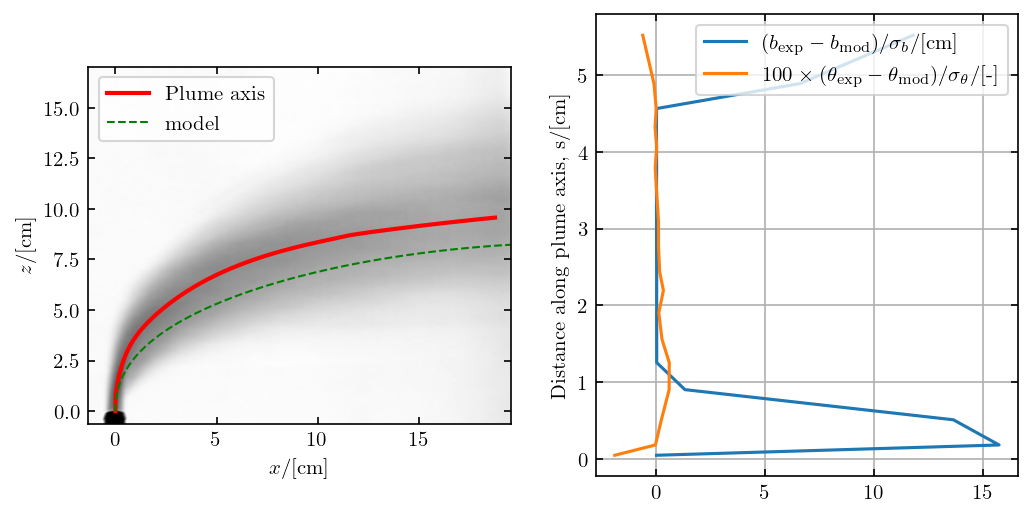

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(8,4))

# On an image of the experimental plume, show the plume trajectories for
# 1) GCTA, 2) our initial guess, 3) the model solution
data, xexp, zexp, extent = load_expt_data(exptNo)
if data.mean() < .5:
    data = 1. - data
ax[0].imshow(data, extent=extent, cmap=plt.cm.gray)
ax[0].invert_yaxis()
ax[0].set_xlabel(r'$x$/[cm]')
ax[0].set_ylabel(r'$z$/[cm]')
# 1) GCTA
ax[0].plot(xexp, zexp, '-r', label='Plume axis', lw=2)
# 2) our initial guess
# ax[0].plot(exptData.axisLocn_x, exptData.axisLocn_y, 'r-', label='Init. guess', lw=2)
# 3) the model solution
ax[0].plot(xmod, zmod, '--g', label='model', lw=1)
ax[0].set_xlim((extent[:2]))
ax[0].legend(loc=2)

n = 100
ax[1].plot(res[:,0], sexp, '-', label=r'$(b_{\mathrm{exp}} - b_{\mathrm{mod}})/\sigma_b$/[cm]')
ax[1].plot(res[:,1] * n, sexp, '-', label=r'$%s \times (\theta_{\mathrm{exp}} - \theta_{\mathrm{mod}})/\sigma_{\theta}$/[-]' % n)
ax[1].legend(loc=1, fancybox=True, framealpha=.8)
ax[1].grid()
ax[1].set_ylabel('Distance along plume axis, s/[cm]')

fig.savefig('plumeAnalyser_solution.png')

# ax[1].set_title('Objective fn: %.3f' % objFn)

(*Left*) Image of experimental plume with calculated and estimated trajectories.  (*Right*) Difference between experimental (guessed) and model solutions as a function of the distance along the plume axis.  

# To do:
- Make a grid of possible initial conditions and run the model for each case.  DONE
- Compare these solutions against the experimental data, computing an objective funtion for each case.  DONE
- Identify which cases produce minima in the objective function.  DONE
- Work in the downhill simplex (or other minimisation routine) to look for minima of the objective function.
- Plot the plume width along with axis track on averaged image.  

In [1]:
# # Uncomment the following line to transform this notebook into a latex file
# !jupyter nbconvert --to latex plumeAnalyser.ipynb

In [11]:
# Now run pdflatex plumeAnalyser from the command line